In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Загрузка данных
df = pd.read_csv("data/Superstore.csv", encoding="ISO-8859-1")

# Преобразуем даты в datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

# Посмотрим на базовые данные
print(df[["Order Date", "Product Name", "Sales"]].head())

  Order Date                                       Product Name     Sales
0 2013-11-09                  Bush Somerset Collection Bookcase  261.9600
1 2013-11-09  Hon Deluxe Fabric Upholstered Stacking Chairs,...  731.9400
2 2013-06-13  Self-Adhesive Address Labels for Typewriters b...   14.6200
3 2012-10-11      Bretford CR4500 Series Slim Rectangular Table  957.5775
4 2012-10-11                     Eldon Fold 'N Roll Cart System   22.3680


In [62]:
# 2. Преобразуем нужные данные
df = df[["Sales", "Discount", "Quantity", "Profit"]].dropna()

# 3. Признаки и целевая переменная
X = df[["Sales", "Discount", "Quantity"]]
y = df["Profit"]

# 4. Разделим данные
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Преобразование в полиномиальные признаки
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 6. Обучение модели
model = LinearRegression()
model.fit(X_train, y_train)

# 7. Предсказание
y_pred = model.predict(X_test)

# 8. Оценка модели
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 83592.67
R² Score: -0.72


In [63]:
#sorting coefficients
import numpy as np
coefficients = model.coef_
sorted_indices = np.argsort(coefficients)
sorted_coefficients = coefficients[sorted_indices]
sorted_features = X.columns[sorted_indices]

In [66]:
sorted_features

Index(['Discount', 'Quantity', 'Sales'], dtype='object')

In [7]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Загрузка
df = pd.read_csv("data/Superstore.csv", encoding="ISO-8859-1")
df = df[["Order Date", "Product Name", "Sales", "Discount", "Profit", "Category", "Sub-Category", "Region", "Quantity"]].dropna()

# 2. Фичи из даты
df["Order Date"] = pd.to_datetime(df["Order Date"],  dayfirst=True)
df["year"] = df["Order Date"].dt.year
df["month"] = df["Order Date"].dt.month
df["day"] = df["Order Date"].dt.day
df["dayofweek"] = df["Order Date"].dt.dayofweek
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

# 3. Цена за штуку (фичи от себя)
df["Unit_Price"] = df["Sales"] / df["Quantity"]
df["Discounted_Price"] = df["Unit_Price"] * (1 - df["Discount"])

# 4. Категориальные переменные — лейбл энкодинг
cat_cols = ["Product Name", "Category", "Sub-Category", "Region"]
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# 5. Признаки и цель
features = ["Product Name", "Category", "Sub-Category", "Region", 
            "Sales", "Discount", "Profit", "Unit_Price", "Discounted_Price", 
            "year", "month", "day", "dayofweek", "is_weekend"]

X = df[features]
y = df["Quantity"]

# 6. LightGBM с KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = []

for train_idx, val_idx in kf.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    train_set = lgb.Dataset(X_train, y_train)
    val_set = lgb.Dataset(X_val, y_val, reference=train_set)
    
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'verbose': -1
    }
    
    model = lgb.train(params, train_set, num_boost_round=1000, 
                      valid_sets=[train_set, val_set]
                      )
    
    y_pred = model.predict(X_val)
    rmse = mean_squared_error(y_val, y_pred)
    rmse_scores.append(rmse)

print(f"Среднее RMSE по 5 фолдам: {np.mean(rmse_scores):.3f}")

Среднее RMSE по 5 фолдам: 0.058


In [22]:
from datetime import datetime

def predict_quantity_by_date(input_date_str):
    input_date = pd.to_datetime(input_date_str)
    
    # Фичи из даты
    features_date = {
        "year": input_date.year,
        "month": input_date.month,
        "day": input_date.day,
        "dayofweek": input_date.dayofweek,
        "is_weekend": int(input_date.dayofweek in [5, 6])
    }

    # Уникальные товары
    product_base = df.drop_duplicates(subset=["Product Name"])[
        ["Product Name", "Category", "Sub-Category", "Region", "Sales", "Discount", "Profit", "Unit_Price", "Discounted_Price"]
    ].copy()

    for key, value in features_date.items():
        product_base[key] = value

    # Сохраняем оригинальные названия
    product_base["Original_Product_Name"] = product_base["Product Name"]

    # Кодируем в новые колонки, не затирая оригинальные
    product_base["Encoded_Product_Name"] = LabelEncoder().fit_transform(product_base["Product Name"])
    product_base["Encoded_Category"] = LabelEncoder().fit_transform(product_base["Category"])
    product_base["Encoded_Sub_Category"] = LabelEncoder().fit_transform(product_base["Sub-Category"])
    product_base["Encoded_Region"] = LabelEncoder().fit_transform(product_base["Region"])

    # Подготовка фичей
    input_X = product_base[[
        "Encoded_Product_Name", "Encoded_Category", "Encoded_Sub_Category", "Encoded_Region",
        "Sales", "Discount", "Profit", "Unit_Price", "Discounted_Price",
        "year", "month", "day", "dayofweek", "is_weekend"
    ]]

    predicted_quantities = model.predict(input_X)
    product_base["Predicted_Quantity"] = predicted_quantities

    result = product_base.sort_values(by="Predicted_Quantity", ascending=False)[
        ["Original_Product_Name", "Predicted_Quantity"]
    ].head(10)

    return result.rename(columns={"Original_Product_Name": "Product Name"})

In [23]:
top_products = predict_quantity_by_date("2025-05-01")
print(top_products)

      Product Name  Predicted_Quantity
2947          1617           13.449450
113           1195           13.309330
660           1473           12.932949
2062          1732           12.241907
412           1181           12.210566
6158          1462           12.066641
343           1482           11.908863
2582          1036           11.866085
4678           910           11.761844
886            585           11.724466


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_products_by_date(input_date_str):
    top_products = predict_quantity_by_date(input_date_str)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_products,
        x="Predicted_Quantity",
        y="Product Name",
        palette="Blues_r"
    )
    plt.title(f"ТОП-10 товаров по прогнозу спроса на {input_date_str}", fontsize=14)
    plt.xlabel("Прогнозируемое количество продаж")
    plt.ylabel("Товар")
    plt.tight_layout()
    plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_3612\4133610032.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


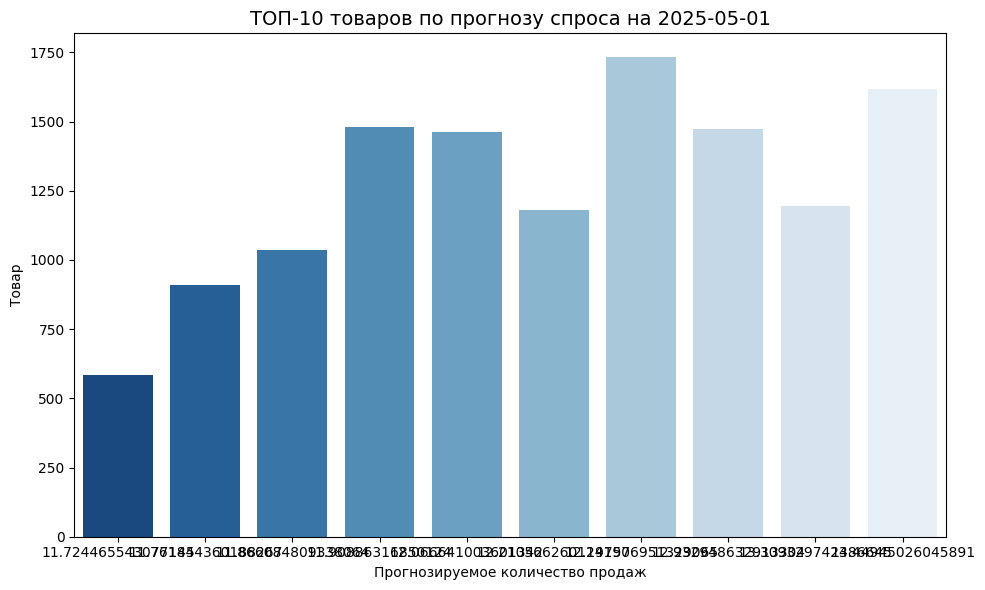

In [25]:
plot_top_products_by_date("2025-05-01")

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Загрузка данных
df = pd.read_csv("data/Superstore.csv", encoding="ISO-8859-1")

# Преобразуем даты в datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [25]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [26]:
#drop duplicates
df.drop_duplicates(inplace=True)

In [17]:
#delete columns
df1 = df.drop(columns=['Row ID', 'Customer Name', 'Country', 'Postal Code', 'Category', 'Product Name', 'State', 'Region'])
df1

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,City,Product ID,Sub-Category,Sales,Quantity,Discount,Profit
0,CA-2013-152156,2013-11-09,12-11-2013,Second Class,CG-12520,Consumer,Henderson,FUR-BO-10001798,Bookcases,261.9600,2,0.00,41.9136
1,CA-2013-152156,2013-11-09,12-11-2013,Second Class,CG-12520,Consumer,Henderson,FUR-CH-10000454,Chairs,731.9400,3,0.00,219.5820
2,CA-2013-138688,2013-06-13,17-06-2013,Second Class,DV-13045,Corporate,Los Angeles,OFF-LA-10000240,Labels,14.6200,2,0.00,6.8714
3,US-2012-108966,2012-10-11,18-10-2012,Standard Class,SO-20335,Consumer,Fort Lauderdale,FUR-TA-10000577,Tables,957.5775,5,0.45,-383.0310
4,US-2012-108966,2012-10-11,18-10-2012,Standard Class,SO-20335,Consumer,Fort Lauderdale,OFF-ST-10000760,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2011-110422,2011-01-22,24-01-2011,Second Class,TB-21400,Consumer,Miami,FUR-FU-10001889,Furnishings,25.2480,3,0.20,4.1028
9990,CA-2014-121258,2014-02-27,04-03-2014,Standard Class,DB-13060,Consumer,Costa Mesa,FUR-FU-10000747,Furnishings,91.9600,2,0.00,15.6332
9991,CA-2014-121258,2014-02-27,04-03-2014,Standard Class,DB-13060,Consumer,Costa Mesa,TEC-PH-10003645,Phones,258.5760,2,0.20,19.3932
9992,CA-2014-121258,2014-02-27,04-03-2014,Standard Class,DB-13060,Consumer,Costa Mesa,OFF-PA-10004041,Paper,29.6000,4,0.00,13.3200


In [18]:
#number of duplicates
df1.duplicated().sum()

np.int64(1)

In [19]:
#output duplicates
df1[df1.duplicated()]

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,City,Product ID,Sub-Category,Sales,Quantity,Discount,Profit
3406,US-2011-150119,2011-04-23,27-04-2011,Standard Class,LB-16795,Home Office,Columbus,FUR-CH-10002965,Chairs,281.372,2,0.3,-12.0588
